In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/thyroid-cancer-recurrence-dataset/filtered_thyroid_data.csv


## Title: Thyroid Cancer Recurrence Dataset

#### Description: A dataset containing clinical, demographic, and diagnostic information to predict the likelihood of recurrence in thyroid cancer patients. It includes features like age, gender, tumor size, lymph node status, and treatment details.

## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/thyroid-cancer-recurrence-dataset/filtered_thyroid_data.csv')

In [3]:
df.head()

,Age,Gender,Hx Radiothreapy,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
0,27,F,No,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Indeterminate,No
1,34,F,No,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
2,30,F,No,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
3,62,F,No,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
4,62,F,No,No,Micropapillary,Multi-Focal,Low,T1a,N0,M0,I,Excellent,No


In [4]:
df.tail()

,Age,Gender,Hx Radiothreapy,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
378,72,M,Yes,Right,Papillary,Uni-Focal,High,T4b,N1b,M1,IVB,Biochemical Incomplete,Yes
379,81,M,Yes,Extensive,Papillary,Multi-Focal,High,T4b,N1b,M1,IVB,Structural Incomplete,Yes
380,72,M,No,Bilateral,Papillary,Multi-Focal,High,T4b,N1b,M1,IVB,Structural Incomplete,Yes
381,61,M,Yes,Extensive,Hurthel cell,Multi-Focal,High,T4b,N1b,M0,IVA,Structural Incomplete,Yes
382,67,M,No,Bilateral,Papillary,Multi-Focal,High,T4b,N1b,M0,IVA,Structural Incomplete,Yes


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 383 entries, 0 to 382
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Age              383 non-null    int64 
 1   Gender           383 non-null    object
 2   Hx Radiothreapy  383 non-null    object
 3   Adenopathy       383 non-null    object
 4   Pathology        383 non-null    object
 5   Focality         383 non-null    object
 6   Risk             383 non-null    object
 7   T                383 non-null    object
 8   N                383 non-null    object
 9   M                383 non-null    object
 10  Stage            383 non-null    object
 11  Response         383 non-null    object
 12  Recurred         383 non-null    object
dtypes: int64(1), object(12)
memory usage: 39.0+ KB


In [6]:
df.describe()

,Age
count,383.000000
mean,40.866841
std,15.134494
min,15.000000
25%,29.000000
50%,37.000000
75%,51.000000
max,82.000000


In [7]:
df.isnull().sum()

Age                0
Gender             0
Hx Radiothreapy    0
Adenopathy         0
Pathology          0
Focality           0
Risk               0
T                  0
N                  0
M                  0
Stage              0
Response           0
Recurred           0
dtype: int64

In [8]:
df.duplicated().sum()

53

In [9]:
df.dtypes

Age                 int64
Gender             object
Hx Radiothreapy    object
Adenopathy         object
Pathology          object
Focality           object
Risk               object
T                  object
N                  object
M                  object
Stage              object
Response           object
Recurred           object
dtype: object

In [10]:
df.shape

(383, 13)

In [11]:
df.columns

Index(['Age', 'Gender', 'Hx Radiothreapy', 'Adenopathy', 'Pathology',
       'Focality', 'Risk', 'T', 'N', 'M', 'Stage', 'Response', 'Recurred'],
      dtype='object')

## Data visualizations

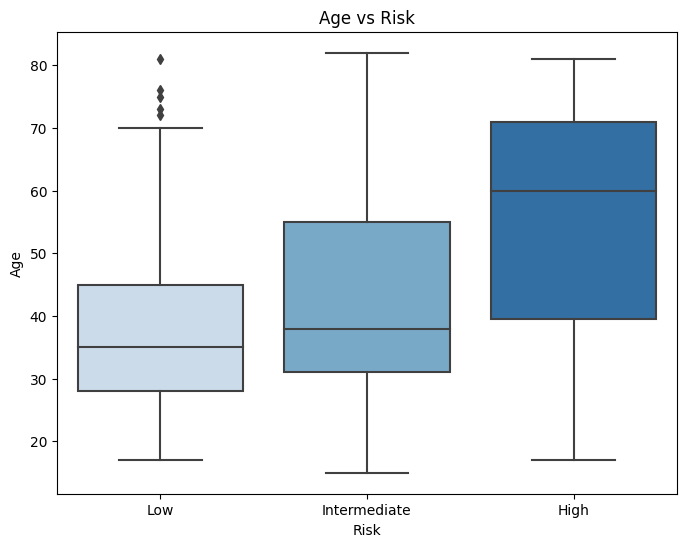

In [12]:
# 1. Age vs Risk - Boxplot
plt.figure(figsize=(8,6))
sns.boxplot(x='Risk', y='Age', data=df, palette="Blues")
plt.title('Age vs Risk')
plt.show()

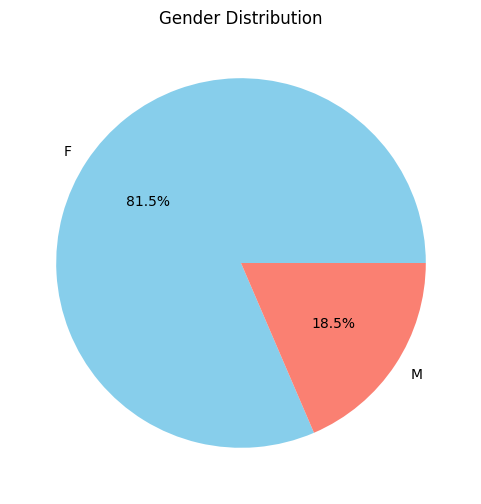

In [13]:
# 2. Gender Distribution - Pie chart
plt.figure(figsize=(6,6))
df['Gender'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['skyblue', 'salmon'])
plt.title('Gender Distribution')
plt.ylabel('')
plt.show()

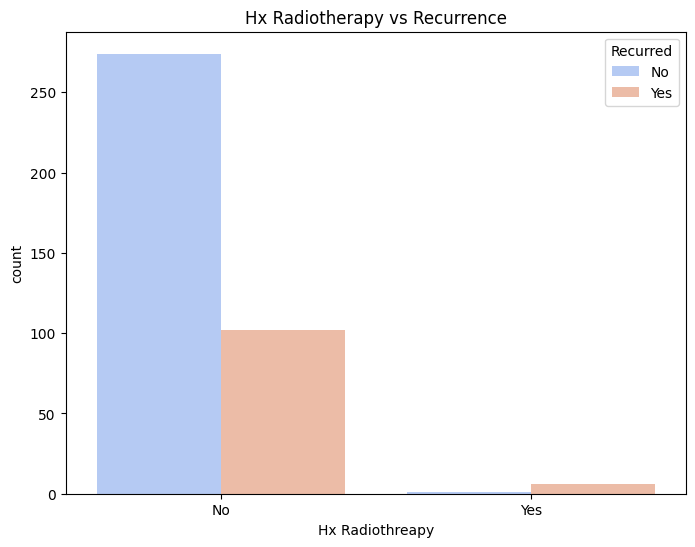

In [14]:
# 3. Hx Radiotherapy vs Recurrence - Grouped Bar Chart
plt.figure(figsize=(8,6))
sns.countplot(x='Hx Radiothreapy', hue='Recurred', data=df, palette='coolwarm')
plt.title('Hx Radiotherapy vs Recurrence')
plt.show()

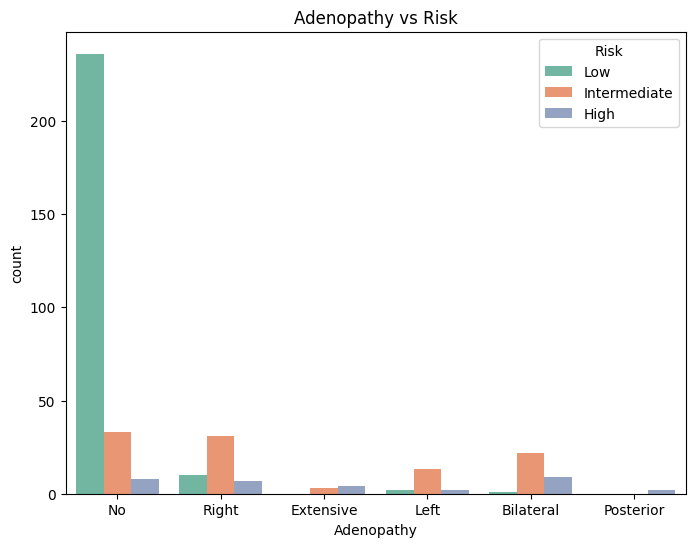

In [15]:
# 4. Adenopathy vs Risk - Stacked Bar Chart
plt.figure(figsize=(8,6))
sns.countplot(x='Adenopathy', hue='Risk', data=df, palette='Set2')
plt.title('Adenopathy vs Risk')
plt.show()

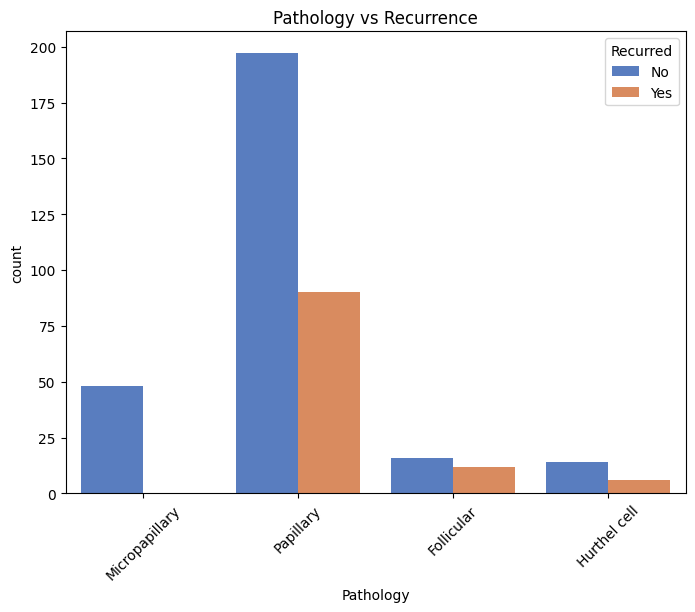

In [16]:
# 5. Pathology vs Recurrence - Bar Chart
plt.figure(figsize=(8,6))
sns.countplot(x='Pathology', hue='Recurred', data=df, palette='muted')
plt.title('Pathology vs Recurrence')
plt.xticks(rotation=45)
plt.show()

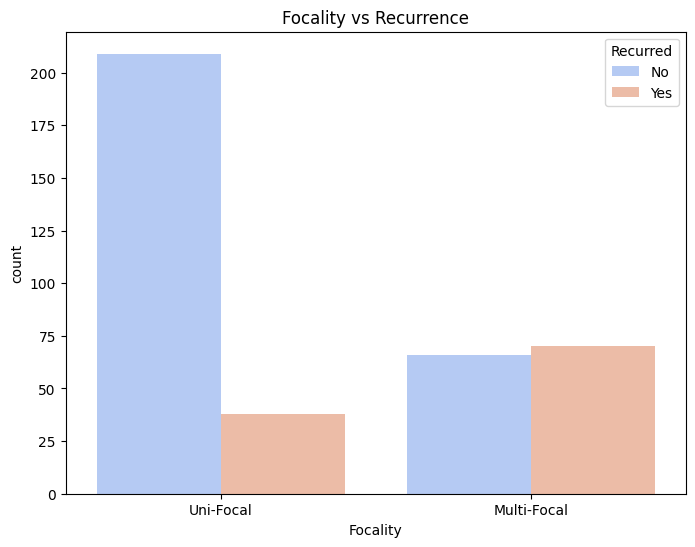

In [17]:
# 6. Focality vs Recurrence - Stacked Bar Chart
plt.figure(figsize=(8,6))
sns.countplot(x='Focality', hue='Recurred', data=df, palette='coolwarm')
plt.title('Focality vs Recurrence')
plt.show()


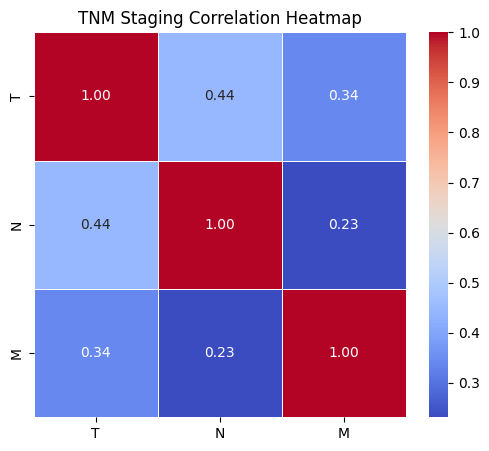

In [18]:
import re

# Assuming df is your dataset

# Function to extract numeric part from strings like 'T1a', 'T2', etc.
def extract_numeric_value(column):
    return column.apply(lambda x: int(re.sub(r'\D', '', str(x))))

# 1. Apply the extraction to the 'T', 'N', and 'M' columns
df['T'] = extract_numeric_value(df['T'])
df['N'] = extract_numeric_value(df['N'])
df['M'] = extract_numeric_value(df['M'])

# 2. Now we can compute correlations and plot the heatmap
tnm_data = df[['T', 'N', 'M']].corr()
plt.figure(figsize=(6,5))
sns.heatmap(tnm_data, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('TNM Staging Correlation Heatmap')
plt.show()

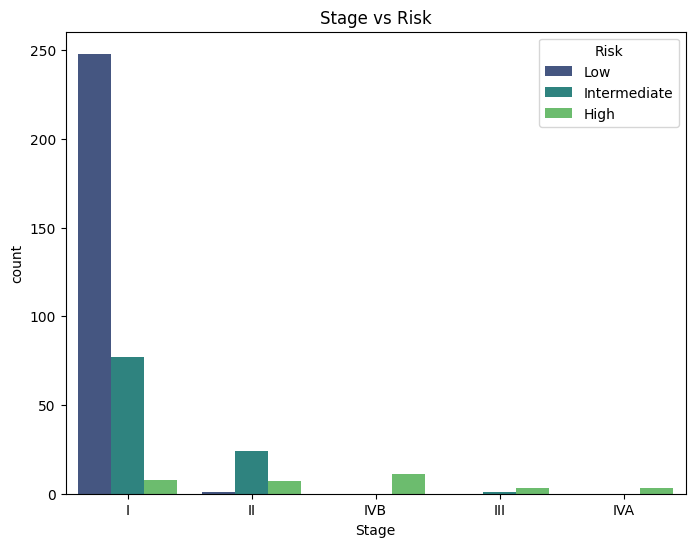

In [19]:
# 8. Stage vs Risk - Bar Chart
plt.figure(figsize=(8,6))
sns.countplot(x='Stage', hue='Risk', data=df, palette='viridis')
plt.title('Stage vs Risk')
plt.show()

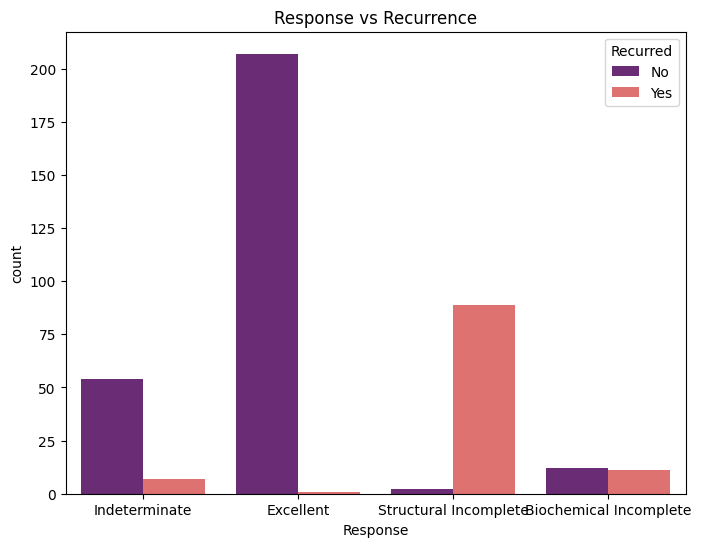

In [20]:
# 9. Response vs Recurrence - Stacked Bar Chart
plt.figure(figsize=(8,6))
sns.countplot(x='Response', hue='Recurred', data=df, palette='magma')
plt.title('Response vs Recurrence')
plt.show()

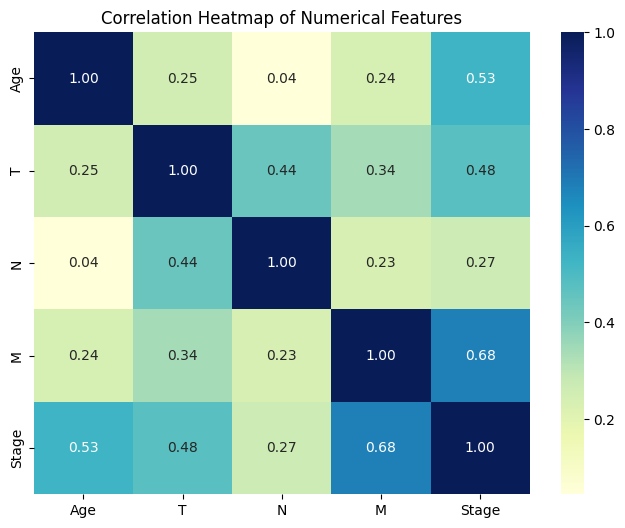

In [21]:
# Function to convert categorical columns to numeric codes
def convert_to_numeric(df, columns):
    for col in columns:
        df[col] = df[col].astype('category').cat.codes
    return df

# 1. Convert 'T', 'N', 'M', and 'Stage' to numeric values by mapping categorical values to integers
df = convert_to_numeric(df, ['T', 'N', 'M', 'Stage'])

# 2. Now we can compute correlations and plot the heatmap
numerical_cols = df[['Age', 'T', 'N', 'M', 'Stage']]  # Make sure all these columns are numeric now
plt.figure(figsize=(8,6))
sns.heatmap(numerical_cols.corr(), annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

## Predictive modeling

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

In [23]:
# 1. Label Encoding for categorical variables
label_encoder = LabelEncoder()

In [24]:
# Apply label encoding to all non-numeric columns
df['Gender'] = label_encoder.fit_transform(df['Gender'])
df['Hx Radiothreapy'] = label_encoder.fit_transform(df['Hx Radiothreapy'])
df['Adenopathy'] = label_encoder.fit_transform(df['Adenopathy'])
df['Pathology'] = label_encoder.fit_transform(df['Pathology'])
df['Focality'] = label_encoder.fit_transform(df['Focality'])
df['Risk'] = label_encoder.fit_transform(df['Risk'])
df['Response'] = label_encoder.fit_transform(df['Response'])
df['Recurred'] = label_encoder.fit_transform(df['Recurred'])  # Target variable

In [25]:
# 2. Split the data into features (X) and target (y)
X = df.drop('Recurred', axis=1)  # Features
y = df['Recurred']  # Target


In [26]:
# 3. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [27]:
# 4. Initialize the models
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "Support Vector Classifier": SVC(),
    "Decision Tree": DecisionTreeClassifier(),
    "K-Nearest Neighbors": KNeighborsClassifier()
}

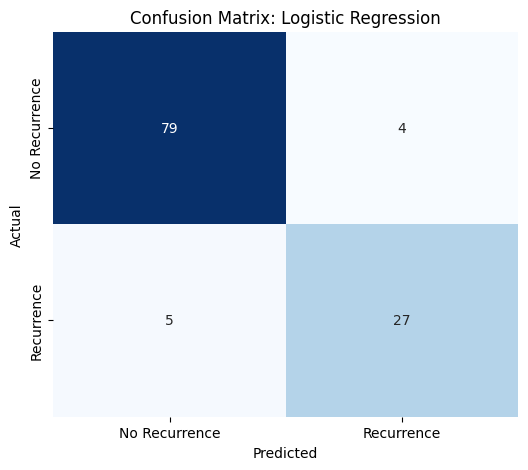

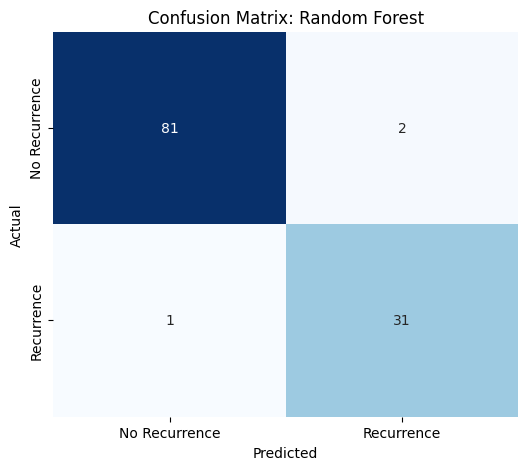

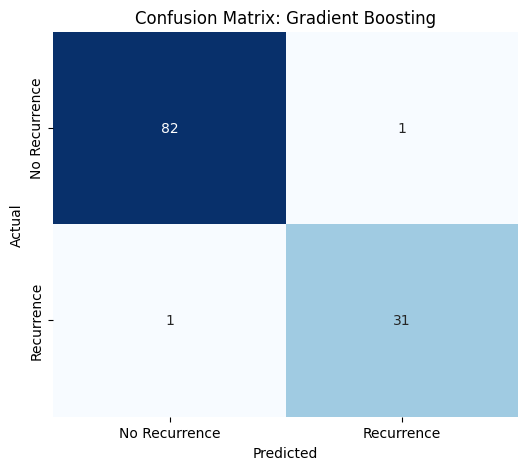

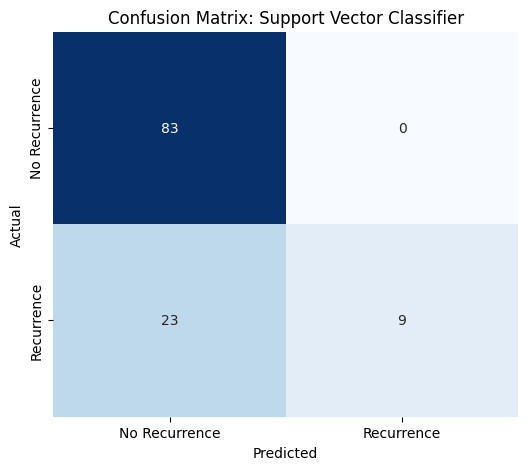

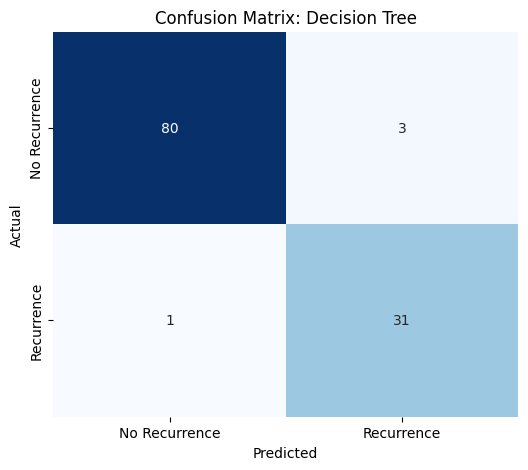

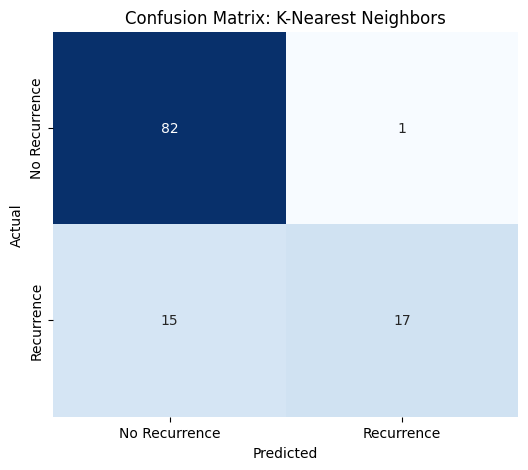

In [28]:
# 5. Train models, evaluate accuracy and plot confusion matrix
results = {}

for name, model in models.items():
    # Fit model
    model.fit(X_train, y_train)
    
    # Predict on test data
    y_pred = model.predict(X_test)
    
    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred) * 100  # Convert to percentage
    results[name] = accuracy
    
    # Display confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=['No Recurrence', 'Recurrence'], yticklabels=['No Recurrence', 'Recurrence'])
    plt.title(f'Confusion Matrix: {name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

In [29]:
# 6. Print the accuracy results for each model
print("Model Accuracy Results (in percentage):")
for model, accuracy in results.items():
    print(f"{model}: {accuracy:.2f}%")

Model Accuracy Results (in percentage):
Logistic Regression: 92.17%
Random Forest: 97.39%
Gradient Boosting: 98.26%
Support Vector Classifier: 80.00%
Decision Tree: 96.52%
K-Nearest Neighbors: 86.09%


## Thank you..pls upvote!!!!